# 02 · Preparación, split, baseline y modelos preliminares

**Proyecto integrador – Data Mining Tools (CC209) – TP1**

Continúa desde `01_eda.ipynb`. Cubre los puntos 4 a 10 del alcance del TP1: decisiones de preparación, separación de datos, pipeline reproducible, baseline, modelos preliminares, evaluación y plan hacia el TF1.

Todo el preprocesamiento vive en `src/features.py` y la separación en `src/data.py`; aquí solo se usan.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import set_config
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_validate

from src import config, data, evaluate, features

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
set_config(display="diagram")
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
AZUL, NARANJA = "#4C72B0", "#DD8452"


def guardar(nombre):
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Decisiones de preparación

Cada decisión sale de un hallazgo del notebook 01. La columna "riesgo" recoge lo que podría salir mal con la decisión tomada.

| Problema detectado | Decisión | Alternativa descartada | Riesgo que asumimos |
|---|---|---|---|
| `duration` solo existe después de la llamada | Excluirla del modelo | Usarla (mejores métricas) | Ninguno para el uso real; las métricas serán más bajas que las de trabajos que sí la usan |
| `day_of_week` contiene el día del mes | Renombrar a `day` | Calcular el día de la semana | No se puede reconstruir sin el año |
| Faltantes en `poutcome`, `contact`, `education`, `job` | Categoría propia `unknown` | Imputar la moda / eliminar filas | En `contact` el faltante identifica un periodo, no al cliente: el modelo puede aprender algo que no se repetirá |
| `pdays = -1` es un código | Indicador `contactado_antes`; `pdays` pasa a 0 en esos casos | Dejar el -1 | En un modelo lineal, `pdays = 0` todavía se parece a "contactado hoy"; el indicador compensa |
| Asimetría y extremos en `balance`, `campaign`, `previous`, `pdays` | Logaritmo (con signo para `balance`) y luego estandarización | Eliminar outliers por IQR | Se conservan posibles errores de registro (p. ej. `previous = 275`), aunque con influencia reducida |
| 16 filas repetidas al quitar `duration` | Conservarlas | Eliminarlas | Si son un mismo contacto duplicado, podrían caer en train y en validation a la vez (0.04 % de los datos) |
| Categóricas nominales | One-hot con `handle_unknown="ignore"` | Codificación ordinal | Con 48 columnas finales no hay problema de dimensionalidad |
| Binarias yes/no | Una sola columna 0/1 | Dos columnas | — |

No eliminamos ninguna fila. La única columna que se descarta es `duration`.

Las dos primeras filas de la tabla y la conversión de `y` a 0/1 se aplican en `data.clean()` porque son correcciones fijas que no aprenden nada de los datos. El resto está dentro del pipeline.

In [2]:
df = data.clean(data.load_raw())
print(df.shape)
df.head(3)

(45211, 18)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,orden
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,0,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,0,2


## 2. Separación de los datos

**Estrategia.** *Hold-out* estratificado por `y` con semilla fija (`SEED = 42`):

| Conjunto | Proporción | Para qué se usa |
|---|---|---|
| Train | 60 % | Ajustar el preprocesamiento y los modelos; validación cruzada de 5 particiones |
| Validation | 20 % | Comparar modelos y elegir el umbral de decisión |
| Test | 20 % | **No se usa en el TP1.** Queda reservado para la evaluación final del TF1 |

**Por qué estas proporciones.** Con 45 211 filas y 11.7 % de positivos, un 20 % deja alrededor de 1 058 suscriptores en validation y otros tantos en test, suficiente para que las métricas de la clase positiva no bailen demasiado. La estratificación garantiza que los tres conjuntos tengan la misma tasa.

**Por qué no tocamos test todavía.** En el TF1 vamos a ajustar hiperparámetros y posiblemente cambiar variables. Si miramos test ahora, cada decisión posterior estaría influida por él y dejaría de ser una estimación honesta.

**Medidas contra el data leakage.**
1. Se excluye `duration`.
2. El split se hace **antes** de cualquier análisis que involucre a `y` (el EDA del notebook 01 usa solo train).
3. Todo lo que aprende parámetros (medias y desviaciones del escalado, categorías del one-hot) está dentro de un `Pipeline` y se ajusta únicamente con train. En la validación cruzada se reajusta en cada partición.
4. El umbral de decisión se elige en validation, no en test.

**Limitación de esta estrategia.** El split aleatorio mezcla contactos de 2008 con contactos de 2010. Es válido para comparar modelos entre sí, pero no simula el uso real (entrenar con campañas pasadas y puntuar una futura). Lo medimos en la sección 8.

In [3]:
train, val, test = data.train_val_test_split(df)
X_train, y_train = data.split_xy(train)
X_val, y_val = data.split_xy(val)

pd.DataFrame({
    "filas": [len(train), len(val), len(test)],
    "% del total": [len(s) / len(df) * 100 for s in (train, val, test)],
    "suscriptores": [s["y"].sum() for s in (train, val, test)],
    "tasa de suscripción %": [s["y"].mean() * 100 for s in (train, val, test)],
}, index=["train", "validation", "test"]).round(2)

,filas,% del total,suscriptores,tasa de suscripción %
train,27126,60.0,3173,11.7
validation,9042,20.0,1058,11.7
test,9043,20.0,1058,11.7


In [4]:
assert set(train.index).isdisjoint(val.index) and set(train.index).isdisjoint(test.index) and set(val.index).isdisjoint(test.index)
assert "duration" not in X_train.columns and "y" not in X_train.columns and "orden" not in X_train.columns
print("Sin solapamiento entre conjuntos. Columnas de entrada:", list(X_train.columns))

Sin solapamiento entre conjuntos. Columnas de entrada: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']


## 3. Flujo reproducible de preprocesamiento

`features.build_pipeline(modelo)` devuelve un único objeto con tres pasos:

1. **`features`** – `add_features`: crea `contactado_antes` y reemplaza el `-1` de `pdays`. Es una operación fila a fila, sin parámetros aprendidos.
2. **`preprocess`** – `ColumnTransformer`:

| Bloque | Variables | Transformación | ¿Aprende de train? |
|---|---|---|---|
| `num` | `age`, `day` | `StandardScaler` | Sí (media y desviación) |
| `num_signed_log` | `balance` | log con signo → `StandardScaler` | Sí |
| `num_log` | `campaign`, `previous`, `pdays` | `log1p` → `StandardScaler` | Sí |
| `flags` | `contactado_antes` | Sin cambios | No |
| `cat` | `job`, `marital`, `education`, `contact`, `month`, `poutcome` | Faltante → `unknown`, luego one-hot | Sí (lista de categorías) |
| `bin` | `default`, `housing`, `loan` | One-hot con una sola columna | Sí |

3. **`model`** – el estimador.

Como todo está en un solo `Pipeline`, llamar a `.fit(X_train, y_train)` ajusta las transformaciones solo con train, y `.predict_proba(X_nuevo)` aplica exactamente las mismas a datos nuevos. El mismo objeto es el que se guarda en `models/` y el que usará la aplicación del TF1.

El escalado no es necesario para los modelos de árboles, pero sí para la regresión logística. Usamos el mismo preprocesamiento para todos para que la comparación sea pareja.

In [5]:
pipe_demo = features.build_pipeline(LogisticRegression(max_iter=2000))
pipe_demo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001FFD8C4A3E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDicti

In [6]:
pre = pipe_demo[:-1].fit(X_train)
nombres = pipe_demo.named_steps["preprocess"].get_feature_names_out()
print(f"{X_train.shape[1]} columnas de entrada -> {len(nombres)} columnas tras el preprocesamiento")
print(list(nombres))

15 columnas de entrada -> 48 columnas tras el preprocesamiento
['age', 'day', 'balance', 'campaign', 'previous', 'pdays', 'contactado_antes', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'default_yes', 'housing_yes', 'loan_yes']


## 4. Métricas: cuáles y por qué

El resultado del modelo se usa para **ordenar** clientes, y la clase que interesa es la minoritaria. Por eso:

| Métrica | Qué responde en este problema | Rol |
|---|---|---|
| **PR-AUC** (average precision) | Qué tan bien quedan los suscriptores arriba del ranking. Un modelo al azar obtiene la tasa base (0.117). | Principal, para comparar modelos |
| **Captura en el top 20 %** | Si solo llamo al 20 % mejor puntuado, ¿a qué porcentaje de los suscriptores alcanzo? Al azar sería 20 %. | La que entiende el negocio; es nuestro criterio de utilidad (≥ 50 %) |
| **Lift en el top 20 %** | Cuántas veces mejor que llamar al azar (captura / 0.20). | Misma información, otra escala |
| ROC-AUC | Probabilidad de que un suscriptor tenga mayor puntaje que un no suscriptor. | Secundaria. No depende de la tasa base, sirve para comparar entre periodos |
| Precisión / recall | De los que llamo, cuántos aceptan / de los que aceptarían, a cuántos llamo. | Para describir la decisión con un umbral fijo |

**No usamos accuracy** como criterio: predecir siempre "no" da 88.3 % y no sirve para nada.

## 5. Baselines

Dos referencias, para responder "¿el modelo mejora frente a una solución trivial o simple?":

- **Trivial** – `DummyClassifier(strategy="prior")`: asigna a todos la misma probabilidad (la tasa base). Equivale a llamar en cualquier orden.
- **Regla de negocio** – lo que haría un supervisor sin ningún modelo, usando el hallazgo más fuerte del EDA: llamar primero a quienes aceptaron en la campaña anterior, luego a los demás contactados antes, y al final al resto. Dentro de cada grupo el orden es el del archivo (los datos ya vienen barajados por el split).

In [7]:
def puntaje_regla(X):
    # 2 = aceptó la campaña anterior, 1 = fue contactado antes, 0 = resto
    return (X["poutcome"] == "success").astype(int) * 2 + (X["pdays"] != -1).astype(int)


resultados = {}

dummy = features.build_pipeline(DummyClassifier(strategy="prior")).fit(X_train, y_train)
resultados["Baseline trivial (Dummy)"] = evaluate.ranking_metrics(y_val, dummy.predict_proba(X_val)[:, 1])
resultados["Baseline regla de negocio"] = evaluate.ranking_metrics(y_val, puntaje_regla(X_val))

print(val.assign(grupo=puntaje_regla(X_val)).groupby("grupo")["y"].agg(["size", "mean"]).round(3))
pd.DataFrame(resultados).T.round(3)

       size   mean
grupo             
0      7349  0.091
1      1381  0.130
3       312  0.670


,pr_auc,roc_auc,captura_top20,lift_top20
Baseline trivial (Dummy),0.117,0.500,0.207,1.035
Baseline regla de negocio,0.245,0.616,0.373,1.867


**Lo que muestran los datos.** El Dummy obtiene PR-AUC = 0.117 (la tasa base) y capta el 20.7 % de los suscriptores en el top 20 %, es decir, lo mismo que llamar al azar. La regla de negocio sube a PR-AUC = 0.245 y capta el 37.3 % (lift 1.87). En validation, el grupo que aceptó la campaña anterior suscribe 67.0 %, pero son solo 312 clientes de 9 042.

**Interpretación.** La regla es un baseline serio: casi duplica al azar sin entrenar nada. Su límite es que solo sabe ordenar al 19 % de clientes con historial; para el 81 % restante no tiene criterio. Un modelo se justifica si logra ordenar también a esos clientes. Esta es la referencia que hay que superar, no el Dummy.

## 6. Modelos preliminares

Comparamos tres alternativas elegidas por lo que vimos en el EDA:

| Modelo | Por qué lo incluimos |
|---|---|
| **Regresión logística** (`class_weight="balanced"`) | Modelo lineal simple e interpretable. Es la referencia: si un modelo más complejo no la supera con claridad, no se justifica. |
| **Random Forest** (300 árboles, `min_samples_leaf=5`, `class_weight="balanced_subsample"`) | Captura relaciones no lineales (la U de la edad) e interacciones sin que tengamos que crearlas a mano. |
| **HistGradientBoosting** (parámetros por defecto) | Boosting de árboles; suele rendir bien en datos tabulares mixtos y entrena rápido. |

Los hiperparámetros son valores razonables **sin ajuste**; el ajuste sistemático queda para el TF1. Cada modelo se evalúa de dos formas: validación cruzada estratificada de 5 particiones dentro de train (da una media y una desviación, para saber si las diferencias son ruido) y el conjunto de validation.

In [8]:
modelos = {
    "Regresión logística": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=config.SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=config.SEED),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.SEED)

ajustados, scores_val, cv_resumen = {}, {}, {}
for nombre, modelo in modelos.items():
    pipe = features.build_pipeline(clone(modelo))
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["average_precision", "roc_auc"])
    cv_resumen[nombre] = {
        "cv_pr_auc": r["test_average_precision"].mean(),
        "cv_pr_auc_sd": r["test_average_precision"].std(),
        "cv_roc_auc": r["test_roc_auc"].mean(),
    }
    ajustados[nombre] = pipe.fit(X_train, y_train)
    scores_val[nombre] = pipe.predict_proba(X_val)[:, 1]
    resultados[nombre] = evaluate.ranking_metrics(y_val, scores_val[nombre])

tabla = pd.DataFrame(resultados).T.join(pd.DataFrame(cv_resumen).T)
tabla.to_csv(config.REPORTS_DIR / "metricas_validacion.csv", index_label="modelo")
tabla.round(3)

,pr_auc,roc_auc,captura_top20,lift_top20,cv_pr_auc,cv_pr_auc_sd,cv_roc_auc
Baseline trivial (Dummy),0.117,0.500,0.207,1.035,NaN,NaN,NaN
Baseline regla de negocio,0.245,0.616,0.373,1.867,NaN,NaN,NaN
Regresión logística,0.416,0.773,0.562,2.812,0.398,0.011,0.764
Random Forest,0.465,0.802,0.633,3.166,0.431,0.006,0.791
HistGradientBoosting,0.478,0.803,0.631,3.157,0.427,0.013,0.790


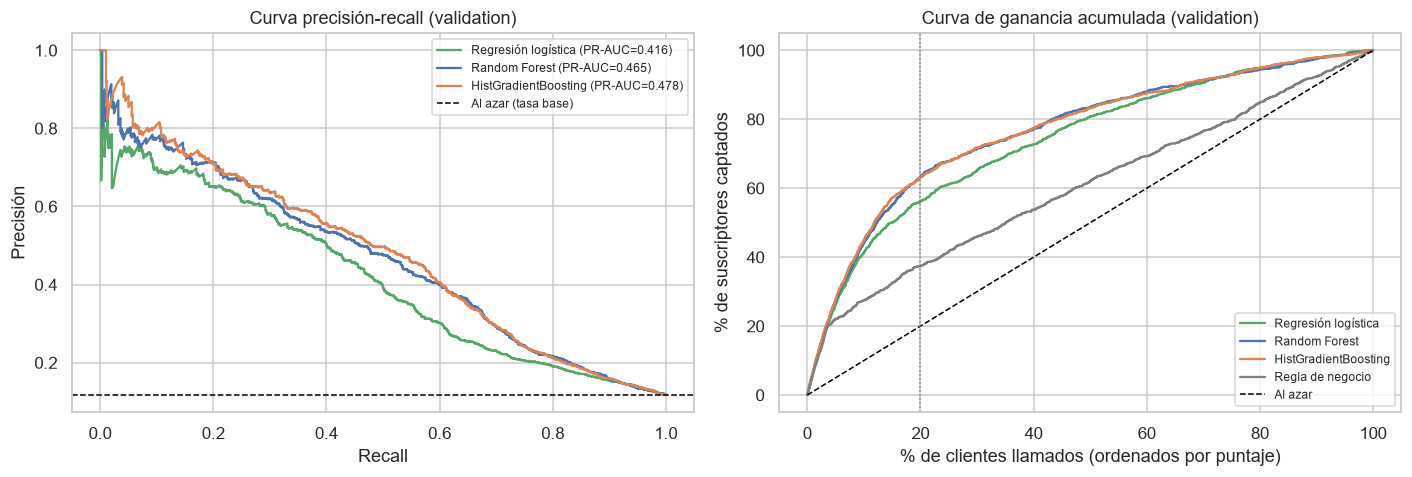

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colores = dict(zip(modelos, ["#55A868", AZUL, NARANJA]))

for nombre, s in scores_val.items():
    p, r, _ = precision_recall_curve(y_val, s)
    axes[0].plot(r, p, label=f"{nombre} (PR-AUC={resultados[nombre]['pr_auc']:.3f})", color=colores[nombre])
    g = evaluate.gain_curve(y_val, s)
    axes[1].plot(g["pct_llamados"] * 100, g["pct_captados"] * 100, label=nombre, color=colores[nombre])

axes[0].axhline(y_val.mean(), color="black", ls="--", lw=1, label="Al azar (tasa base)")
axes[0].set(xlabel="Recall", ylabel="Precisión", title="Curva precisión-recall (validation)")
axes[0].legend(fontsize=8)

g = evaluate.gain_curve(y_val, puntaje_regla(X_val))
axes[1].plot(g["pct_llamados"] * 100, g["pct_captados"] * 100, color="gray", label="Regla de negocio")
axes[1].plot([0, 100], [0, 100], color="black", ls="--", lw=1, label="Al azar")
axes[1].axvline(20, color="gray", ls=":", lw=1)
axes[1].set(xlabel="% de clientes llamados (ordenados por puntaje)", ylabel="% de suscriptores captados",
            title="Curva de ganancia acumulada (validation)")
axes[1].legend(fontsize=8)
guardar("10_curvas_modelos")

**Lo que muestran los datos.**

- Los tres modelos superan a ambos baselines. En validation la captura en el top 20 % es 56.2 % (logística), 63.3 % (Random Forest) y 63.1 % (HistGradientBoosting), frente a 37.3 % de la regla de negocio.
- Los dos modelos de árboles superan a la regresión logística en todas las métricas (PR-AUC de validación cruzada 0.43 frente a 0.40, con desviaciones de alrededor de 0.01).
- Random Forest y HistGradientBoosting están **empatados**: en validación cruzada 0.431 ± 0.006 y 0.427 ± 0.013; en validation 0.465 y 0.478. La diferencia cambia de signo según dónde se mida y es menor que la variación entre particiones.
- Las métricas de validation son algo más altas que las de validación cruzada en los tres modelos (por ejemplo 0.478 frente a 0.427).

**Interpretación.**

- **Criterio de utilidad 1 (captar ≥ 50 % llamando al 20 %): se cumple** en validation con los tres modelos. Con HistGradientBoosting, llamar a 1 de cada 5 clientes alcanza a 63 de cada 100 suscriptores, unas 3.2 veces más que al azar.
- **Criterio 2 (superar la regla de negocio): se cumple**, con 26 puntos porcentuales más de captura.
- La ventaja de los árboles sobre el modelo lineal es coherente con las relaciones no lineales vistas en el EDA (edad en U), aunque no hemos comprobado que esa sea la causa.
- No podemos afirmar que HistGradientBoosting sea mejor que Random Forest. Lo tomamos como **modelo preliminar** por razones prácticas: entrena varias veces más rápido y el artefacto guardado es pequeño, lo que facilita la búsqueda de hiperparámetros y el despliegue del TF1. La elección definitiva se hará con ajuste de hiperparámetros.
- Que validation dé mejor que la validación cruzada puede deberse a que en validation el modelo se entrena con todo train (en cada partición de la validación cruzada solo con el 80 %) y a variación propia de la muestra. Para comparar modelos nos fiamos más de la validación cruzada porque promedia cinco evaluaciones.
- **Qué significa PR-AUC ≈ 0.45.** Es casi cuatro veces la tasa base, pero queda lejos de 1: el modelo ordena mucho mejor que el azar y aun así se equivoca bastante. Sin `duration`, lo que se sabe del cliente antes de llamar solo explica una parte de la decisión.

## 7. De la probabilidad a la decisión: umbral

El modelo devuelve una probabilidad; el call center necesita una lista de "llamar / no llamar". El umbral habitual de 0.5 no tiene sentido aquí: con 11.7 % de positivos, casi ningún cliente llega a 0.5 en un modelo sin pesos de clase.

Para el TP1 fijamos el umbral según una **capacidad operativa supuesta**: el call center puede llamar al 20 % de la lista. El umbral es el puntaje que deja por encima al 20 % de validation. Es un supuesto nuestro; el dataset no informa costos por llamada ni ganancia por depósito.

,umbral,precision,recall,f1,pct_llamados
Umbral 0.5,0.500,0.652,0.274,0.386,0.049
Umbral top 20 %,0.129,0.369,0.631,0.466,0.200


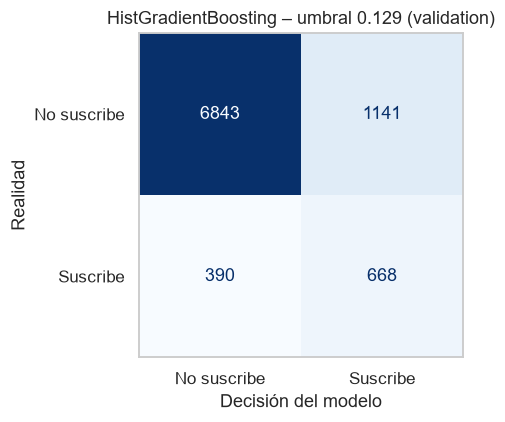

In [10]:
ELEGIDO = "HistGradientBoosting"
s = scores_val[ELEGIDO]
umbral = float(np.quantile(s, 0.80))

comparacion = pd.DataFrame([
    evaluate.threshold_metrics(y_val, s, 0.5),
    evaluate.threshold_metrics(y_val, s, umbral),
], index=["Umbral 0.5", "Umbral top 20 %"]).round(3)
display(comparacion)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_val, (s >= umbral).astype(int), ax=ax, cmap="Blues",
                                        display_labels=["No suscribe", "Suscribe"], colorbar=False)
ax.set(title=f"{ELEGIDO} – umbral {umbral:.3f} (validation)", xlabel="Decisión del modelo", ylabel="Realidad")
ax.grid(False)
guardar("11_matriz_confusion")

**Lo que muestran los datos.** Con umbral 0.5 el modelo solo recomendaría llamar al 4.9 % de los clientes y encontraría al 27.4 % de los suscriptores. Con el umbral del top 20 % (0.129) la precisión es 36.9 % y el recall 63.1 %.

**Interpretación en términos del problema.**
- De cada 100 clientes que el modelo manda a llamar, unos 37 suscriben. Llamando al azar serían unos 12.
- El costo: el 37 % de los suscriptores queda fuera de la lista (falsos negativos) y 63 de cada 100 llamadas recomendadas siguen sin vender (falsos positivos).
- Qué error pesa más depende de cifras que no tenemos (costo de una llamada, margen de un depósito). Si el depósito deja mucho margen y la llamada es barata, convendría bajar el umbral y llamar a más gente. Por eso reportamos la curva de ganancia completa y no solo un punto.
- El umbral 0.129 no debe leerse como "12.9 % de probabilidad": aún no hemos verificado que las probabilidades estén calibradas.

## 8. Pruebas de robustez

Tres comprobaciones para no quedarnos con una sola cifra. Ninguna usa el conjunto de test.

### 8.1 ¿Cuánto inflaría las métricas `duration`?

In [11]:
X_train_d, _ = data.split_xy(train, drop_leakage=False)
X_val_d, _ = data.split_xy(val, drop_leakage=False)
con_duration = features.build_pipeline(HistGradientBoostingClassifier(random_state=config.SEED),
                                       extra_numeric=["duration"]).fit(X_train_d, y_train)

robustez = {
    "Sin duration (modelo del proyecto)": resultados[ELEGIDO],
    "Con duration (solo como referencia)": evaluate.ranking_metrics(y_val, con_duration.predict_proba(X_val_d)[:, 1]),
}
pd.DataFrame(robustez).T.round(3)

,pr_auc,roc_auc,captura_top20,lift_top20
Sin duration (modelo del proyecto),0.478,0.803,0.631,3.157
Con duration (solo como referencia),0.649,0.944,0.862,4.310


### 8.2 ¿Cuánto depende el modelo de `month` y `day`?

In [12]:
sin_fecha = features.build_pipeline(HistGradientBoostingClassifier(random_state=config.SEED))
ct = sin_fecha.named_steps["preprocess"]
ct.transformers = [(n, t, [c for c in cols if c not in ("month", "day")]) for n, t, cols in ct.transformers]
sin_fecha.fit(X_train, y_train)

pd.DataFrame({
    "Con month y day": resultados[ELEGIDO],
    "Sin month ni day": evaluate.ranking_metrics(y_val, sin_fecha.predict_proba(X_val)[:, 1]),
}).T.round(3)

,pr_auc,roc_auc,captura_top20,lift_top20
Con month y day,0.478,0.803,0.631,3.157
Sin month ni day,0.425,0.773,0.559,2.793


### 8.3 ¿Qué pasa si se entrena con el pasado y se evalúa en el futuro?

Juntamos train y validation, los ordenamos por su posición original en el archivo (que sigue el orden cronológico) y entrenamos con el 80 % más antiguo para evaluar en el 20 % más reciente. Es lo más parecido al uso real que permiten los datos.

In [13]:
desarrollo = pd.concat([train, val]).sort_values("orden")
corte = int(len(desarrollo) * 0.8)
pasado, futuro = desarrollo.iloc[:corte], desarrollo.iloc[corte:]
X_pas, y_pas = data.split_xy(pasado)
X_fut, y_fut = data.split_xy(futuro)
print(f"Tasa de suscripción -> pasado: {y_pas.mean():.1%}   futuro: {y_fut.mean():.1%}")

temporal = {}
for nombre, modelo in modelos.items():
    pipe = features.build_pipeline(clone(modelo)).fit(X_pas, y_pas)
    temporal[nombre] = evaluate.ranking_metrics(y_fut, pipe.predict_proba(X_fut)[:, 1])
temporal["Regla de negocio"] = evaluate.ranking_metrics(y_fut, puntaje_regla(X_fut))
temporal["Al azar"] = {"pr_auc": y_fut.mean(), "roc_auc": 0.5, "captura_top20": 0.2, "lift_top20": 1.0}

tabla_temporal = pd.DataFrame(temporal).T
tabla_temporal.to_csv(config.REPORTS_DIR / "metricas_temporal.csv", index_label="modelo")
tabla_temporal.round(3)

Tasa de suscripción -> pasado: 6.8%   futuro: 31.3%


,pr_auc,roc_auc,captura_top20,lift_top20
Regresión logística,0.488,0.686,0.365,1.826
Random Forest,0.472,0.683,0.318,1.590
HistGradientBoosting,0.478,0.680,0.340,1.698
Regla de negocio,0.445,0.612,0.324,1.621
Al azar,0.313,0.500,0.200,1.000


**Lo que muestran los datos.**

1. **`duration`.** Al incluirla, la ROC-AUC pasa de 0.803 a 0.944 y la captura en el top 20 % de 63.1 % a 86.2 %.
2. **`month` y `day`.** Al quitarlas, la PR-AUC baja de 0.478 a 0.425 y la captura de 63.1 % a 55.9 %.
3. **Prueba temporal.** El periodo "futuro" tiene una tasa de suscripción de 31.3 % frente a 6.8 % del "pasado". Entrenando con el pasado, la ROC-AUC cae de alrededor de 0.80 a 0.68 en los tres modelos y la captura en el top 20 % queda entre 31.8 % y 36.5 %. La regla de negocio capta 32.4 % en ese mismo periodo. La regresión logística es la que mejor resiste; Random Forest queda ligeramente por debajo de la regla.

(En la prueba temporal las PR-AUC no son comparables con las de la sección 6 porque la tasa base es otra: 0.313 en lugar de 0.117. Por eso comparamos con ROC-AUC, captura y lift.)

**Interpretación.**

- El salto con `duration` confirma el leakage: esas métricas son las que se verían en un proyecto que la incluyera, y no se podrían obtener en la práctica. Nuestras cifras son más modestas, pero corresponden a información realmente disponible antes de llamar.
- El modelo sigue siendo útil sin `month` ni `day` (55.9 % de captura, aún por encima de la regla y del criterio de 50 %), pero aproximadamente una quinta parte de su ventaja sobre la regla viene de esas dos variables. Como sospechamos que `month` refleja el tipo de campaña y no una estacionalidad estable, esa parte del rendimiento es la menos confiable.
- **El resultado más importante del TP1 es el de la prueba temporal: el criterio de utilidad se cumple con split aleatorio y no se cumple cuando se simula el uso real.** En ese escenario los modelos apenas igualan a la regla de negocio.
- Nuestra hipótesis es que el banco cambió su forma de seleccionar clientes hacia el final del periodo (la tasa se multiplica por más de cuatro), de modo que el modelo aprendió patrones de las campañas masivas de 2008-2009 que no se trasladan a las campañas selectivas de 2010. No podemos verificarlo con estos datos. También es posible que parte de la caída se deba a que el "futuro" es una población distinta (clientes ya filtrados por el banco).
- Que el modelo más simple resista mejor sugiere que los árboles se están ajustando en exceso a particularidades del periodo de entrenamiento. Es un argumento para no descartar la regresión logística en el TF1.
- Lo que sí podemos concluir: las cifras de la sección 6 describen qué tan bien se ordenan clientes **dentro del mismo periodo** en que se entrenó. No son una estimación de cómo funcionaría el modelo en la siguiente campaña.

## 9. Primera mirada a qué usa el modelo

No es todavía el análisis de interpretabilidad (eso es parte del TF1, con SHAP o importancia por permutación). Solo revisamos los coeficientes de la regresión logística para comprobar que el modelo se apoya en lo que el EDA mostró y no en algo extraño. Las variables numéricas están estandarizadas, así que los coeficientes son comparables en magnitud.

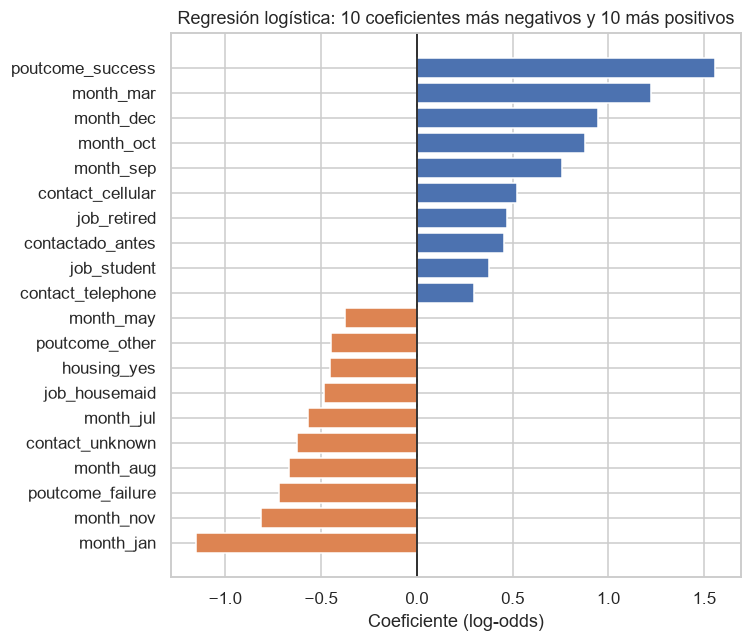

In [14]:
logit = ajustados["Regresión logística"]
coef = pd.Series(logit.named_steps["model"].coef_[0],
                 index=logit.named_steps["preprocess"].get_feature_names_out()).sort_values()
extremos = pd.concat([coef.head(10), coef.tail(10)])
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(extremos.index, extremos.values, color=[NARANJA if v < 0 else AZUL for v in extremos.values])
ax.axvline(0, color="black", lw=1)
ax.set(title="Regresión logística: 10 coeficientes más negativos y 10 más positivos",
       xlabel="Coeficiente (log-odds)")
guardar("12_coeficientes_logit")

**Lo que muestran los datos.** Los coeficientes más positivos son `poutcome_success`, cuatro meses de pocas llamadas (`month_mar`, `month_dec`, `month_oct`, `month_sep`), `contact_cellular`, `job_retired`, `contactado_antes`, `job_student` y `contact_telephone`. Los más negativos son varios meses (`month_jan`, `month_nov`, `month_aug`, `month_jul`), `poutcome_failure`, `contact_unknown`, `job_housemaid`, `housing_yes` y `poutcome_other`.

**Interpretación.**
- Hay coherencia con el EDA: historial de éxito, jubilados, estudiantes y ausencia de deudas empujan hacia la suscripción.
- Nueve de los veinte coeficientes más grandes son meses, y `contact_unknown` (que identifica el primer periodo del archivo) también pesa. Esto respalda la preocupación de la sección 8: una parte del modelo está reconociendo *en qué campaña* ocurrió el contacto.
- Precaución: son coeficientes de un modelo con variables correlacionadas entre sí (ocupación y edad, `pdays` y `previous`), así que el valor individual de cada uno no debe leerse como "el efecto" de esa variable. Y en ningún caso son efectos causales.

## 10. Artefacto del modelo preliminar

In [15]:
artefacto = {"pipeline": ajustados[ELEGIDO], "umbral": umbral, "modelo": ELEGIDO,
             "columnas_entrada": list(X_train.columns)}
ruta = config.MODELS_DIR / "modelo_preliminar.joblib"
joblib.dump(artefacto, ruta)
print(f"Guardado {ruta.relative_to(ROOT)} ({ruta.stat().st_size / 1024:.0f} KB)")

# Comprobación: el artefacto recargado reproduce las mismas probabilidades
recargado = joblib.load(ruta)
assert np.allclose(recargado["pipeline"].predict_proba(X_val)[:, 1], scores_val[ELEGIDO])
print("El pipeline recargado reproduce las predicciones de validation.")

Guardado models\modelo_preliminar.joblib (317 KB)
El pipeline recargado reproduce las predicciones de validation.


## 11. Estado del proyecto y plan hacia el TF1

### Principales hallazgos

1. Solo el 11.7 % de los contactos termina en suscripción, y la variable más predictiva (`duration`) no puede usarse porque se conoce después de la llamada. Excluirla baja la ROC-AUC de 0.94 a 0.80: ese es el precio de un modelo utilizable.
2. Con información previa a la llamada, un modelo de boosting capta el 63 % de los suscriptores llamando al 20 % de los clientes (lift 3.2), frente a 37 % de una regla de negocio y 20 % del azar. Esto vale para contactos del mismo periodo de entrenamiento.
3. Las señales más fuertes son el resultado de la campaña anterior, el perfil (jubilados y estudiantes), no tener préstamos y el mes del contacto.
4. Los datos cambian mucho en el tiempo (la tasa de suscripción pasa de 3 % a 47 %). Entrenando con el pasado y evaluando en el periodo más reciente, la captura cae a 32-37 % y el modelo apenas iguala a la regla de negocio.

### ¿Se cumplieron los criterios de utilidad?

| Criterio | Split aleatorio (validation) | Prueba temporal |
|---|---|---|
| Captar ≥ 50 % de suscriptores llamando al 20 % | Sí (63.1 %) | **No** (34.0 %) |
| Superar a la regla de negocio | Sí (63.1 % vs 37.3 %) | Marginal (34.0 % vs 32.4 %) |
| No usar información posterior a la llamada | Sí | Sí |

(Cifras de HistGradientBoosting.)

### Problemas no resueltos

- No sabemos cuánto del rendimiento se sostendría en una campaña nueva. Es el problema principal.
- Random Forest y HistGradientBoosting están empatados; no hay base todavía para elegir.
- No hemos verificado la calibración de las probabilidades.
- El umbral se fijó con un supuesto de capacidad (20 %), no con costos reales.
- `month` y `contact = unknown` actúan como marcadores de periodo; no hemos decidido si mantenerlas.

### Limitaciones identificadas

- **De los datos:** un solo banco portugués, 2008-2010, durante una crisis financiera; sin año explícito; sin identificador de cliente (un cliente podría estar en train y validation); sin variables macroeconómicas; solo clientes que el banco eligió llamar.
- **Del modelo:** hiperparámetros sin ajustar; un solo split aleatorio más validación cruzada; rendimiento dependiente del periodo.
- **De lo que se puede concluir:** el modelo describe asociaciones, no causas. No permite afirmar que llamar en cierto mes o por celular aumente las suscripciones.

### Plan hacia el TF1

| Actividad | Motivo (evidencia del TP1) | Herramienta prevista |
|---|---|---|
| Validación temporal como esquema principal (particiones crecientes sobre `orden`) | La prueba temporal contradice al split aleatorio | `TimeSeriesSplit` |
| Decidir si se mantienen `month`, `day` y `contact = unknown`, comparando variantes bajo validación temporal | Sección 8.2 y coeficientes | Experimentos registrados en MLflow |
| Ajuste de hiperparámetros de logística, Random Forest y boosting, optimizando PR-AUC | Empate entre modelos sin ajustar | Optuna + validación cruzada |
| Calibración de probabilidades y elección de umbral con escenarios de costo | Umbral actual basado en un supuesto | `CalibratedClassifierCV`, curvas de calibración |
| Segmentación de clientes para ver si hay perfiles con comportamiento distinto y si el error se concentra en alguno | Efectos no lineales y grupos pequeños con tasas muy altas | K-Means / PCA o UMAP sobre las variables de perfil |
| Interpretabilidad global y local | Solo tenemos coeficientes de la logística | SHAP, importancia por permutación |
| Análisis de errores: falsos negativos y falsos positivos por segmento y por periodo | 37 % de suscriptores quedan fuera del top 20 % | Notebook dedicado |
| Aplicación que reciba los datos de un cliente y devuelva probabilidad y recomendación | Entregable del TF1 | Streamlit, cargando `models/*.joblib` |
| Evaluación final única sobre test | Test sigue sin usarse | — |